# Homework 4: SOLUTIONS
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).

 
## Problem 1: Period estimation using Lomb-Scargle periodogram


Below in the notebook is the code that generates Figure 10.17 in the textbook. As it is now, it:
* downloads a dataset of variable stars collected with the [LINEAR](https://en.wikipedia.org/wiki/Lincoln_Near-Earth_Asteroid_Research) telescope,
* selects six of them (as given by the `ids` variable),
* computes the Lomb-Scargle periodogram in the `compute_best_frequencies` function,
* finds the best frequency by looking for the highest peak in the periodiogram, and
* folds the light curves and plots the results.

Either by modifying the code below, or by writing similar code, do the following:

1. Find the frequencies for the first 1000 stars in the LINEAR datasets (i.e., those with IDs in `dataAll.ids[:1000]`, where `dataAll` is the variable containing the LINEAR dataset as defined below).

2. Compute the periods corresponing to the frequencies above, and plot the histogram of periods using 50 bins in range $0 < T < 25$ hours. What do you observe in the histogram?

3. Generate four 6-panel figures analogous to Figure 10.17, for 6 stars (arbitrarily chosen) from the four easily visible peaks, respectivelly. Comment on (dis)similarities of these plots and of stars within each plot.

4. EXTRA CREDIT: compute the histogram in #2 for ALL (about 7000) stars in the data set, not just the first 1000 (note: this will take a while - on a Mac Pro several hours). Modify the histogram range and bin sizes as needed to bring out the features (clusters) in the data. Comment on differences compared to the 1000-star case. Extra credit 20% of this homework! 


## Problem 2

PCA applied to 4-D data for variable stars from the SDSS and LINEAR surveys:

-- SDSS u-g and g-i colors,

-- LINEAR variability period (logP) and variability amplitude (A).

The code below reads the data and, to get you familar with the dataset, plots the 
g-i vs. u-g and A vs. logP diagrams.

You need to run PCA with four components and then

a) plot P2 vs. P1 diagram, and P3 vs. P1 diagram, and P3 vs. P4 diagram. Comment what insights, if any, did PCA analysis bring.

b) plot P1 vs. g-i and P1 vs. logP diagrams; repeat with P2, P3, and P4. Comment what insights, if any, did PCA analysis bring.

## Problem 3

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* What does PCA stand for, and what does it do?  

* What does Lomb-Scargle periodogram do?  

# Homework 4: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np 
from matplotlib import pyplot as plt

# monkey-patch before importing the astroML package 
# np.recfromtxt = np.genfromtxt

from astroML.datasets import fetch_LINEAR_geneva
from astroML.decorators import pickle_results
from astroML.time_series import search_frequencies, lomb_scargle, MultiTermFit
from astroML.datasets import fetch_LINEAR_sample
 
%matplotlib inline

In [2]:
print(np.__version__)
print(np.__file__)

1.26.0
/Users/ivezic/miniforge3/envs/myenvARM31211/lib/python3.12/site-packages/numpy/__init__.py


### Write your solutions below...

## Problem 1

In [3]:
# first we read data about LINEAR sample

# hack to account for some old numpy code in astroML
def recfromtxt_compat(*args, **kwargs):
    kwargs.setdefault("dtype", None)
    kwargs.setdefault("encoding", None)
    kwargs.setdefault("names", None)
    return np.genfromtxt(*args, **kwargs)

np.recfromtxt = recfromtxt_compat


from astroML.datasets import fetch_LINEAR_sample
dataAll = fetch_LINEAR_sample(data_home="astroML_data")  
# the number of LINEAR stars with light curves
len(dataAll.targets)

7010

In [4]:
## some helper code taken from
## https://www.astroml.org/book_figures/chapter10/fig_LINEAR_LS.html

# Figure 10.17 code
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general

#------------------------------------------------------------
# Compute the best frequencies
# @pickle_results('LINEAR_LS.pkl')
def compute_best_frequencies(df, ids, n_eval=10000, n_retry=5, generalized=True):
    results = {}
    for i in ids:
        t, y, dy = df[i].T
        print(" - computing power for %i (%i points)" % (i, len(t)))
        kwargs = dict(generalized=generalized)
        # search_frequencies() is a work horse from astroML
        omega, power = search_frequencies(t, y, dy, n_eval=n_eval,
                                          n_retry=n_retry,
                                          LS_kwargs=kwargs)
        # store the power spectrum, power(omega)
        results[i] = [omega, power]

    return results

# plot phased light curves 
def plot_lightcurves(df, results, ids):
    #------------------------------------------------------------
    # Plot the phased light-curves
    fig = plt.figure(figsize=(5, 6.5))
    fig.subplots_adjust(hspace=0.1, bottom=0.06, top=0.94, left=0.12, right=0.94)

    for i in range(len(ids)):
        # get the data and best-fit angular frequency
        t, y, dy = df[ids[i]].T
        omega, power = results[ids[i]]
        omega_best = omega[np.argmax(power)]
        print(" - omega_0 = %.10g" % omega_best)

        # do a fit to the first 4 Fourier components
        mtf = MultiTermFit(omega_best, 4)
        mtf.fit(t, y, dy)
        phase_fit, y_fit, phased_t = mtf.predict(1000, return_phased_times=True)

        # plot the phased data and best-fit curves
        ax = fig.add_subplot(321 + i)
        ax.errorbar(phased_t, y, dy, fmt='.k', ecolor='gray',
                    lw=1, ms=4, capsize=1.5)
        ax.plot(phase_fit, y_fit, '-b', lw=2)

        ax.set_xlim(0, 1)
        ax.set_ylim(plt.ylim()[::-1])
        ax.yaxis.set_major_locator(plt.MaxNLocator(4))

        ax.text(0.03, 0.04, "ID = %i" % ids[i], ha='left', va='bottom',
                transform=ax.transAxes)
        ax.text(0.03, 0.96, "P = %.2f hr" % (2 * np.pi / omega_best * 24.),
                ha='left', va='top',
                transform=ax.transAxes)

        ylim = ax.get_ylim()
        ax.set_ylim(ylim[0], ylim[0] + 1.1 * (ylim[1] - ylim[0]))

        if i < 4:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        if i % 2 == 0:
            ax.set_ylabel('mag')

        if i in (4, 5):
            ax.set_xlabel('phase')

    return fig 



# modeled after fetch_LINEAR_sample in .../astroML/datasets/LINEAR_sample.py
def getLINEAR_sample(data_home=None, download_if_missing=True):
    """Loader for LINEAR data sample

    Parameters
    ----------
    data_home : optional, default=None
        Specify another download and cache folder for the datasets. By default
        all astroML data is stored in '~/astroML_data'.

    download_if_missing : optional, default=True
        If False, raise a IOError if the data is not locally available
        instead of trying to download the data from the source site.

    Returns
    -------
    data : LINEARdata object
        A custom object which provides access to 7010 selected LINEAR light
        curves.
    """
    data_home = get_data_home(data_home)

    targetlist_file = os.path.join(data_home, os.path.basename(TARGETLIST_URL))
    data_file = os.path.join(data_home, os.path.basename(DATA_URL))

    if not os.path.exists(targetlist_file):
        if not download_if_missing:
            raise IOError('data not present on disk. '
                          'set download_if_missing=True to download')

        targets = download_with_progress_bar(TARGETLIST_URL)
        open(targetlist_file, 'wb').write(targets)

    if not os.path.exists(data_file):
        if not download_if_missing:
            raise IOError('data not present on disk. '
                          'set download_if_missing=True to download')

        databuffer = download_with_progress_bar(DATA_URL)
        open(data_file, 'wb').write(databuffer)

    return LINEARdata(data_file, targetlist_file)

In [5]:
from astroML.datasets.tools import download_with_progress_bar

TARGETLIST_URL = (
    "https://github.com/astroML/astroML-data/raw/main/datasets/"
    "allLINEARfinal_targets.dat.gz"
)

targetlist_file = "allLINEARfinal_targets.dat.gz"
targets = download_with_progress_bar(TARGETLIST_URL)

with open(targetlist_file, "wb") as f:
    f.write(targets)

[=========================================]  303.4kb / 303.4kb   


 - computing power for 14752041 (253 points)
 - computing power for 1009459 (593 points)
 - computing power for 10022663 (246 points)
 - computing power for 10025796 (233 points)
 - computing power for 11375941 (280 points)
 - computing power for 18525697 (211 points)
 - omega_0 = 17.21695506
 - omega_0 = 51.10600808
 - omega_0 = 10.20062676
 - omega_0 = 45.55493503
 - omega_0 = 58.44512277
 - omega_0 = 10.82722772


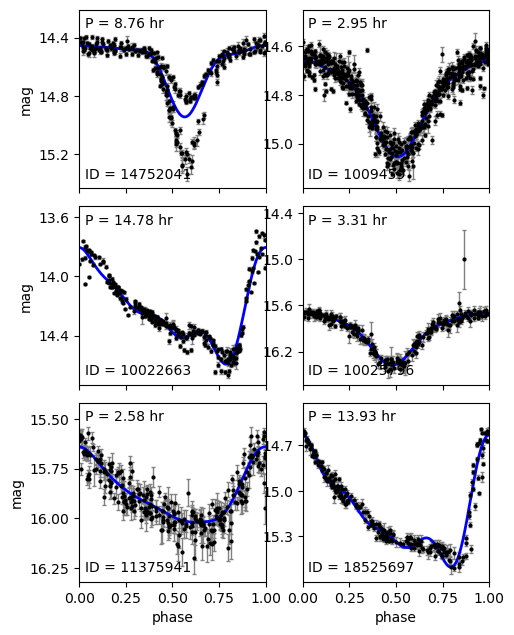

In [6]:
# select a subset of the full dataset
# these are stars shown in Figure 10.17 in the textbook, see
# https://www.astroml.org/book_figures_1ed/chapter10/fig_LINEAR_LS.html
ids = [14752041, 1009459, 10022663, 10025796, 11375941, 18525697]

# Compute the best frequencies
results = compute_best_frequencies(dataAll, ids, n_eval=10000, n_retry=5)

# Plot the phased light-curves
myprettyplot = plot_lightcurves(dataAll, results, ids)

In [7]:
omegas = np.zeros(len(ids))
for i in range(len(ids)):
    # get the data and best-fit angular frequency
    t, y, dy = dataAll[ids[i]].T
    omega, power = results[ids[i]]
    omega_best = omega[np.argmax(power)]
    omegas[i] = omega_best
    print(" - Star #%4d: omega_0, T_0 = %.10g, %.10g" % (i, omega_best, (2 * np.pi / omega_best * 24.)))

 - Star #   0: omega_0, T_0 = 17.21695506, 8.758601439
 - Star #   1: omega_0, T_0 = 51.10600808, 2.950659874
 - Star #   2: omega_0, T_0 = 10.20062676, 14.78305705
 - Star #   3: omega_0, T_0 = 45.55493503, 3.310211007
 - Star #   4: omega_0, T_0 = 58.44512277, 2.580137404
 - Star #   5: omega_0, T_0 = 10.82722772, 13.92752155


In [8]:
# it takes about an hour or more depending on CPU for the full sample of 7000 stars
Nlightcurve = dataAll.ids[:-1].size
NlightcurveProcess = Nlightcurve 
# but here we'll be more modest: 
NlightcurveProcess = 1000

In [9]:
print('processing', NlightcurveProcess, 'light curves...')
idsProcess = dataAll.ids[:NlightcurveProcess]
%time resultsAll = compute_best_frequencies(dataAll, idsProcess, n_eval=10000, n_retry=5)
# 1000 stars: 
# CPU times: user 8min 56s, sys: 2.49 s, total: 8min 59s
# Wall time: 8min 59s 

processing 1000 light curves...
 - computing power for 10003298 (196 points)
 - computing power for 10004892 (269 points)
 - computing power for 10013411 (170 points)
 - computing power for 10021274 (214 points)
 - computing power for 10022663 (246 points)
 - computing power for 10025796 (233 points)
 - computing power for 10028253 (38 points)
 - computing power for 10030349 (255 points)
 - computing power for 10032668 (193 points)
 - computing power for 10038903 (227 points)
 - computing power for 10040133 (257 points)
 - computing power for 10040491 (228 points)
 - computing power for 10045187 (229 points)
 - computing power for 10045615 (101 points)
 - computing power for 10046720 (136 points)
 - computing power for 10047498 (221 points)
 - computing power for 1004849 (607 points)
 - computing power for 1005497 (607 points)
 - computing power for 10064356 (291 points)
 - computing power for 10066464 (274 points)
 - computing power for 10071455 (269 points)
 - computing power for 100

 - computing power for 10609185 (424 points)
 - computing power for 10614690 (221 points)
 - computing power for 10617428 (203 points)
 - computing power for 10619285 (218 points)
 - computing power for 10623386 (385 points)
 - computing power for 10628913 (345 points)
 - computing power for 10634459 (203 points)
 - computing power for 10642127 (210 points)
 - computing power for 10647040 (383 points)
 - computing power for 10648348 (213 points)
 - computing power for 10650256 (165 points)
 - computing power for 10655343 (240 points)
 - computing power for 10655742 (270 points)
 - computing power for 10660789 (237 points)
 - computing power for 10662289 (262 points)
 - computing power for 10662468 (301 points)
 - computing power for 10664456 (342 points)
 - computing power for 1066477 (147 points)
 - computing power for 10671227 (278 points)
 - computing power for 10676064 (319 points)
 - computing power for 10680443 (142 points)
 - computing power for 10689075 (208 points)
 - computin

 - computing power for 11178050 (215 points)
 - computing power for 11187857 (343 points)
 - computing power for 11202454 (218 points)
 - computing power for 11206727 (253 points)
 - computing power for 11212840 (336 points)
 - computing power for 11214551 (276 points)
 - computing power for 11215595 (338 points)
 - computing power for 1122328 (536 points)
 - computing power for 11224124 (318 points)
 - computing power for 11231236 (146 points)
 - computing power for 11233410 (183 points)
 - computing power for 11236739 (148 points)
 - computing power for 11238522 (147 points)
 - computing power for 1124773 (169 points)
 - computing power for 11248827 (205 points)
 - computing power for 11250867 (182 points)
 - computing power for 11256803 (251 points)
 - computing power for 11265995 (232 points)
 - computing power for 11266154 (249 points)
 - computing power for 11266259 (244 points)
 - computing power for 11266421 (241 points)
 - computing power for 1126681 (187 points)
 - computing 

 - computing power for 11863356 (249 points)
 - computing power for 11864180 (236 points)
 - computing power for 11864369 (243 points)
 - computing power for 11864431 (219 points)
 - computing power for 11866538 (265 points)
 - computing power for 11870305 (76 points)
 - computing power for 11872511 (205 points)
 - computing power for 11882477 (198 points)
 - computing power for 11896841 (208 points)
 - computing power for 1190208 (289 points)
 - computing power for 11905739 (206 points)
 - computing power for 11912411 (192 points)
 - computing power for 11917874 (219 points)
 - computing power for 11922992 (193 points)
 - computing power for 11925135 (228 points)
 - computing power for 11929402 (209 points)
 - computing power for 11932308 (243 points)
 - computing power for 11934810 (231 points)
 - computing power for 11935712 (61 points)
 - computing power for 11936793 (231 points)
 - computing power for 11937119 (207 points)
 - computing power for 11942032 (203 points)
 - computing 

 - computing power for 12504572 (404 points)
 - computing power for 12504832 (219 points)
 - computing power for 12505068 (206 points)
 - computing power for 12508478 (213 points)
 - computing power for 12516209 (231 points)
 - computing power for 12517171 (220 points)
 - computing power for 12518025 (195 points)
 - computing power for 12525125 (235 points)
 - computing power for 12526629 (196 points)
 - computing power for 12533027 (167 points)
 - computing power for 12534878 (234 points)
 - computing power for 12536474 (205 points)
 - computing power for 12544799 (161 points)
 - computing power for 12560639 (192 points)
 - computing power for 12561269 (209 points)
 - computing power for 12562559 (219 points)
 - computing power for 12565297 (201 points)
 - computing power for 12566108 (219 points)
 - computing power for 12569794 (193 points)
 - computing power for 12571908 (196 points)
 - computing power for 12578804 (218 points)
 - computing power for 1258617 (259 points)
 - computin

 - computing power for 13077277 (256 points)
 - computing power for 1307948 (262 points)
 - computing power for 1308565 (262 points)
 - computing power for 13087122 (245 points)
 - computing power for 13088404 (258 points)
 - computing power for 13089931 (259 points)
 - computing power for 13093137 (247 points)
 - computing power for 13095415 (254 points)
 - computing power for 13102760 (299 points)
 - computing power for 13103579 (233 points)
 - computing power for 13104605 (275 points)
 - computing power for 13109299 (265 points)
 - computing power for 13112616 (387 points)
 - computing power for 13112627 (239 points)
 - computing power for 13116521 (204 points)
 - computing power for 13119720 (256 points)
 - computing power for 13127606 (205 points)
 - computing power for 13134888 (110 points)
 - computing power for 13135923 (190 points)
 - computing power for 13139150 (127 points)
 - computing power for 13141670 (190 points)
 - computing power for 13142102 (178 points)
 - computing

In [10]:
omegas = np.zeros(len(idsProcess))
for i in range(len(idsProcess)):
    # get the data and best-fit angular frequency
    t, y, dy = dataAll[idsProcess[i]].T
    omega, power = resultsAll[idsProcess[i]]
    omega_best = omega[np.argmax(power)]
    omegas[i] = omega_best
    # print(" - Star #%4d: omega_0, T_0 = %.10g, %.10g" % (i, omega_best, (2 * np.pi / omega_best * 24.)))

### Convert frequencies to periods (in hours):

In [11]:
TT = (2 * np.pi / omegas * 24.)

### Construct and plot the histogram of periods:

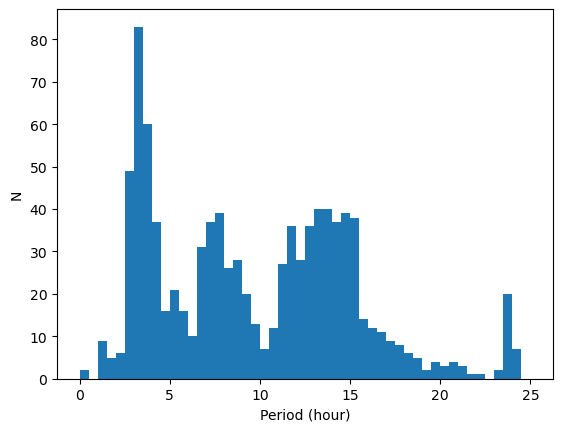

In [12]:
n, bins, patches = plt.hist(TT, 50, range=(0,25))
plt.xlabel('Period (hour)')
plt.ylabel('N')
plt.show()

### Now pick up to 6 ids close to each of the four peaks (determined by eyeballing of the above diagram):

In [13]:
ids_peak1 = idsProcess[(TT >= 3) & (TT < 3.5)][:6]
ids_peak2 = idsProcess[(TT >= 7.5) & (TT < 8)][:6]
ids_peak3 = idsProcess[(TT >= 13.5) & (TT < 14)][:6]
ids_peak4 = idsProcess[(TT >= 23.5) & (TT < 24)][:6]

In [14]:
ids_peak1

array([10025796, 10101561, 10127760, 10178648, 10195209, 10304077])

In [15]:
ids_peak2

array([10132759, 10237955, 10309167,  1032186, 10380706, 10480983])

In [16]:
ids_peak3

array([10021274, 10045187, 10275547, 10324405, 10397805, 10494061])

In [17]:
ids_peak4

array([10322215,  1051415, 10528528, 10642127, 10722407,  1084373])

### And plot the four diagrams:

 - omega_0 = 45.55493503
 - omega_0 = 44.9335195
 - omega_0 = 45.77922442
 - omega_0 = 47.68349511
 - omega_0 = 44.99004599
 - omega_0 = 49.51997338


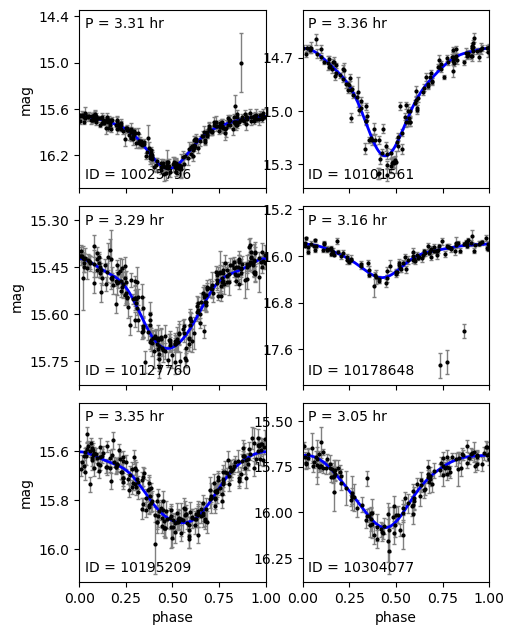

In [18]:
p1 = plot_lightcurves(dataAll, resultsAll, ids_peak1)

 - omega_0 = 19.65703529
 - omega_0 = 19.33778508
 - omega_0 = 19.38175914
 - omega_0 = 19.20132828
 - omega_0 = 19.69191107
 - omega_0 = 19.14952036


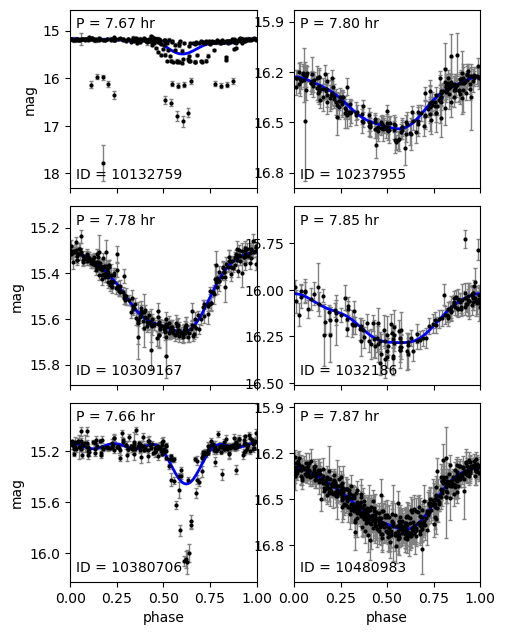

In [19]:
p2 = plot_lightcurves(dataAll, resultsAll, ids_peak2)

 - omega_0 = 10.8907631
 - omega_0 = 11.03110337
 - omega_0 = 10.83847803
 - omega_0 = 11.0257118
 - omega_0 = 10.99564573
 - omega_0 = 10.9083429


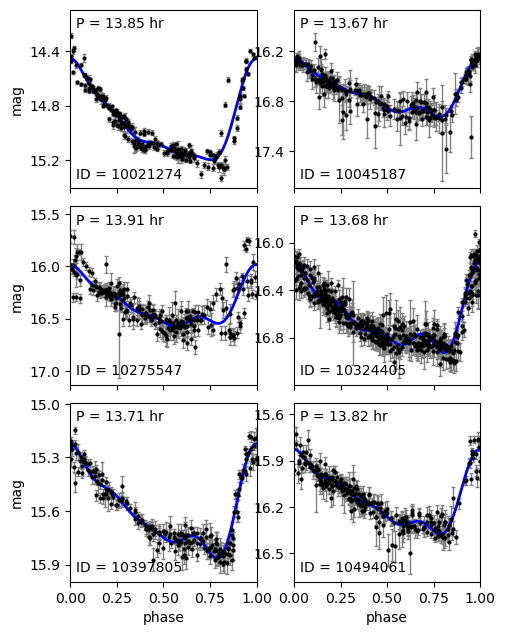

In [20]:
p3 = plot_lightcurves(dataAll, resultsAll, ids_peak3)

 - omega_0 = 6.329473792
 - omega_0 = 6.296647218
 - omega_0 = 6.284439415
 - omega_0 = 6.298189669
 - omega_0 = 6.347005793
 - omega_0 = 6.29641215


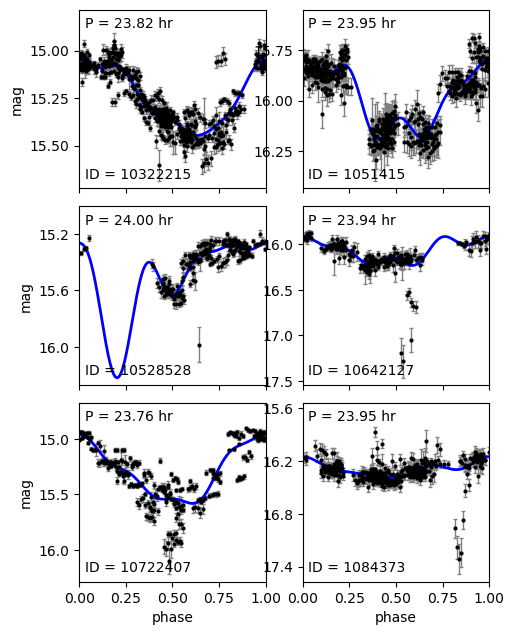

In [21]:
p4 = plot_lightcurves(dataAll, resultsAll, ids_peak4)

## Problem 2

### First obtain data for 6,146 LINEAR stars with confirmed periodic light curves using an astroML built-in function:

In [22]:
data = fetch_LINEAR_geneva()
# N.B. this is a 7-dimensional dataset, but we use only 4 dimensions
ug = data['ug']
gi = data['gi']
logP = data['logP']
A = data['Ampl']

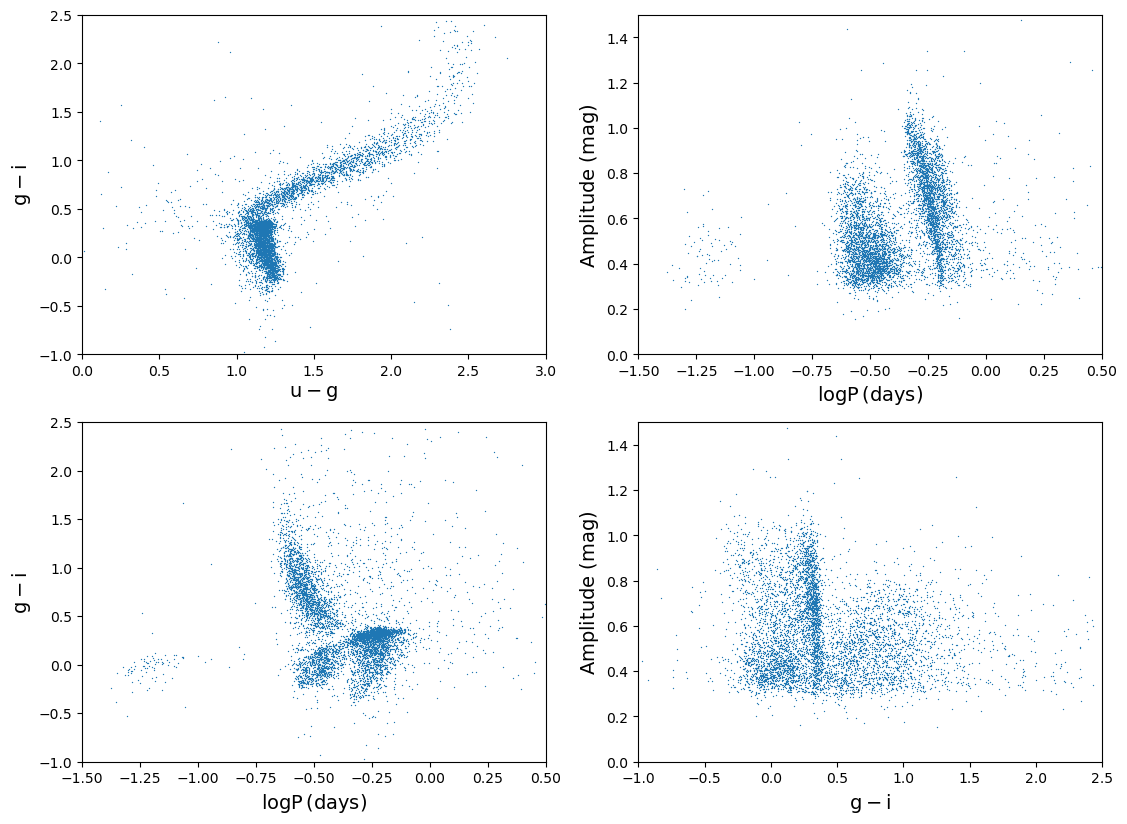

In [23]:
# set up the plot
fig = plt.figure(figsize=(12, 9), facecolor='w')
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.2, bottom=0.1, top=0.93)

# plot the color-color plot
ax1 = fig.add_subplot(221)
ax1.scatter(ug, gi, s=0.9, lw=0)
ax1.set_xlim(0.0, 3.0)
ax1.set_ylim(-1.0, 2.5)
ax1.set_xlabel(r'${\rm u-g}$', color='k', fontsize=14)
ax1.set_ylabel(r'${\rm g-i}$', color='k', fontsize=14)

# plot the A vs. logP plot
ax2 = fig.add_subplot(222)
ax2.scatter(logP, A, s=0.9, lw=0)
ax2.set_xlim(-1.5, 0.5)
ax2.set_ylim(0.0, 1.5)
ax2.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
ax2.set_ylabel(r'${\rm Amplitude \,\, (mag)}$', color='k', fontsize=14)

# g-i vs. logP
ax3 = fig.add_subplot(223)
ax3.scatter(logP, gi, s=0.9, lw=0)
ax3.set_xlim(-1.5, 0.5)
ax3.set_ylim(-1.0, 2.5)
ax3.set_xlabel(r'${\rm logP \, (days)}$', color='k', fontsize=14)
ax3.set_ylabel(r'${\rm g-i}$', color='k', fontsize=14)

# A vs. g-i 
ax4 = fig.add_subplot(224)
ax4.scatter(gi, A, s=0.9, lw=0)
ax4.set_xlim(-1.0, 2.5)
ax4.set_ylim(0.0, 1.5)
ax4.set_xlabel(r'${\rm g-i}$', color='k', fontsize=14)
ax4.set_ylabel(r'${\rm Amplitude \,\, (mag)}$', color='k', fontsize=14)

plt.show()

## and now do PCA...

In [24]:
from sklearn.decomposition import PCA
X = np.column_stack((ug, gi, logP, A))
pca = PCA(n_components=4, whiten=False)  
pca.fit(X)  # call the work horse 
comp = pca.transform(X) # compute the subspace projection of X
mean = pca.mean_ # length 4 mean of the data
components = pca.components_ # 4 x 4 matrix of components
var = pca.explained_variance_ # the length 4 array of eigenvalues
var_rat = pca.explained_variance_ratio_
# and now generate principal axes values
P1 = comp[:,0]
P2 = comp[:,1]
P3 = comp[:,2]
P4 = comp[:,3]
print(np.mean(P1), np.min(P1), np.max(P1))
print(np.mean(P2), np.min(P2), np.max(P2))
print(np.mean(P3), np.min(P3), np.max(P3))
print(np.mean(P4), np.min(P4), np.max(P4))

1.1283594371979463e-15 -100.5190098062269 1.12365169023579
-8.138986104378629e-16 -2.1515679755996944 3.0631018145734124
8.728600154553785e-17 -4.11681685076098 1.842408600608002
-2.1734792437829293e-16 -1.3373569356113013 1.9329680840429608


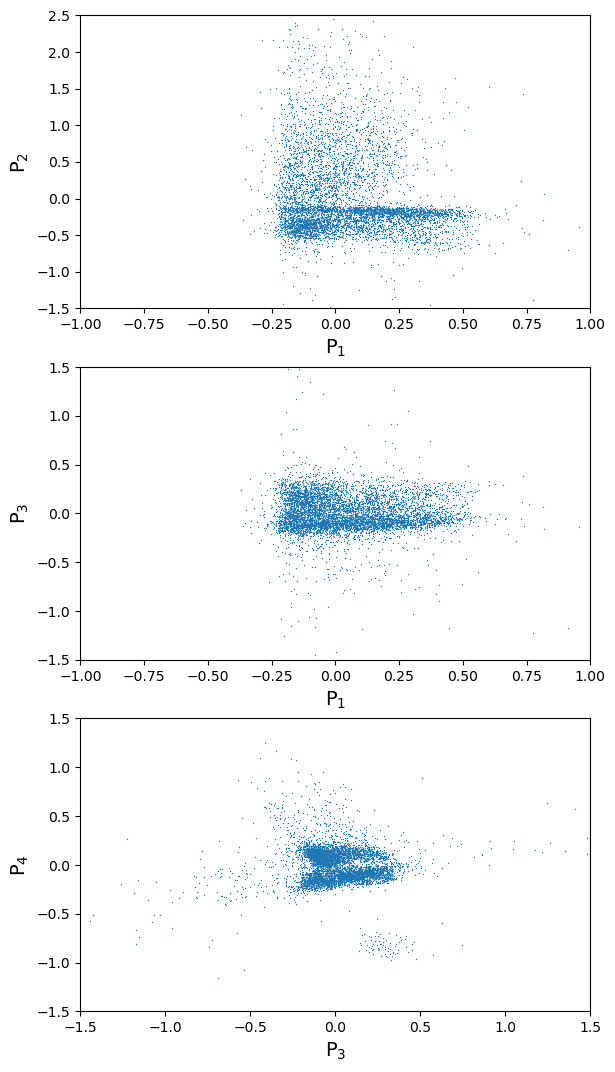

In [25]:
# set up the plot
fig = plt.figure(figsize=(6, 12), facecolor='w')
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.2, bottom=0.1, top=0.93)

# plot the P2 vs. P1 plot
ax1 = fig.add_subplot(311)
ax1.scatter(P1, P2, s=0.9, lw=0)
ax1.set_xlim(-1.0, 1.0)
ax1.set_ylim(-1.5, 2.5)
ax1.set_xlabel(r'${\rm P_1}$', color='k', fontsize=14)
ax1.set_ylabel(r'${\rm P_2}$', color='k', fontsize=14)

# P3 vs. P1
ax2 = fig.add_subplot(312)
ax2.scatter(P1, P3, s=0.9, lw=0)
ax2.set_xlim(-1.0, 1.0)
ax2.set_ylim(-1.5, 1.5)
ax2.set_xlabel(r'${\rm P_1}$', color='k', fontsize=14)
ax2.set_ylabel(r'${\rm P_3}$', color='k', fontsize=14)

# P4 vs. P3
ax2 = fig.add_subplot(313)
ax2.scatter(P3, P4, s=0.9, lw=0)
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_xlabel(r'${\rm P_3}$', color='k', fontsize=14)
ax2.set_ylabel(r'${\rm P_4}$', color='k', fontsize=14)

plt.show()

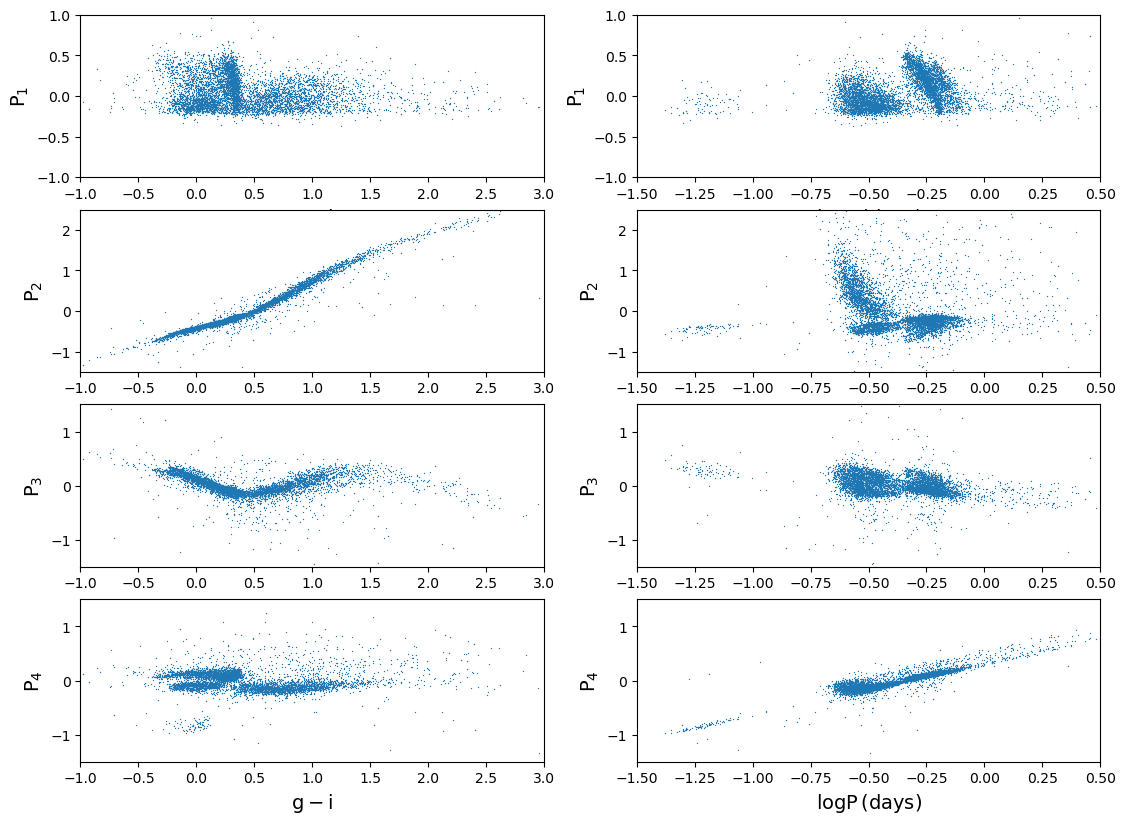

In [26]:
# set up the plot
fig = plt.figure(figsize=(12, 9), facecolor='w')
fig.subplots_adjust(left=0.1, right=0.95, wspace=0.2, bottom=0.1, top=0.93)

def plotPanel(pID, x, y, xMin, xMax, yMin, yMax, xLabel, yLabel):
    ax = fig.add_subplot(pID)
    ax.scatter(x, y, s=0.9, lw=0)
    ax.set_xlim(xMin, xMax)
    ax.set_ylim(yMin, yMax)
    ax.set_xlabel(xLabel, color='k', fontsize=14)
    ax.set_ylabel(yLabel, color='k', fontsize=14)

    
plotPanel(421, gi, P1, -1, 3, -1, 1, r'${\rm g-i}$', r'${\rm P_1}$')
plotPanel(423, gi, P2, -1, 3, -1.5, 2.5, r'${\rm g-i}$', r'${\rm P_2}$')
plotPanel(425, gi, P3, -1, 3, -1.5, 1.5, r'${\rm g-i}$', r'${\rm P_3}$')
plotPanel(427, gi, P4, -1, 3, -1.5, 1.5, r'${\rm g-i}$', r'${\rm P_4}$')

plotPanel(422, logP, P1, -1.5, 0.5, -1, 1, r'${\rm logP \, (days)}$', r'${\rm P_1}$')
plotPanel(424, logP, P2, -1.5, 0.5, -1.5, 2.5, r'${\rm logP \, (days)}$', r'${\rm P_2}$')
plotPanel(426, logP, P3, -1.5, 0.5, -1.5, 1.5, r'${\rm logP \, (days)}$', r'${\rm P_3}$')
plotPanel(428, logP, P4, -1.5, 0.5, -1.5, 1.5, r'${\rm logP \, (days)}$', r'${\rm P_4}$')
 
plt.show()

## Problem 3

PCA stands for Principal Component Analysis. PCA is a method for simplifying complex data by finding the directions in which the data vary the most. PCA first rotates the coordinate system, then it
aligns it with the dominant directions of variation and finally 
ranks those directions by importance. 
The first principal component captures the largest variance, 
the second captures the next largest variance, orthogonal to the first, and so on.

The Lomb–Scargle periodogram is a method for finding periodic signals in data that are sampled at irregular times. Essentially, it fits a single sinusoid to a time series, at a grid of trial frequencies (or periods).